# Generated Formal Theorem Proofs -- analysis

Empirical analysis behind the repository README. The n-gram baselines here are **goal-blind**:
they never read the theorem statement or proof state; they sample from the empirical MLE tactic
distribution of Mathlib4 (LeanDojo Benchmark 4).

Contents:

1. **Tactic frequency structure** of Mathlib4 (from the committed CSV).
2. **Headline comparison**: goal-blind n-gram priors vs. BFS-Prover on miniF2F Test under the same search budget.
3. **Solved-set overlap**: do the baselines solve a strict subset of the neural prover's theorems?
4. **Held-out next-tactic prediction** on the LeanDojo Benchmark 4 validation split, and a measured
   look at *why* the trigram underperforms the unigram in proof search.

Sections 1-3 run entirely from committed artifacts (CPU-only). Section 4 additionally reads
`random/val.json` from a local LeanDojo Benchmark 4 checkout pointed to by the
`LEANDOJO_BENCHMARK_4_DIR` environment variable (the JSON dumps are too large to commit);
it degrades gracefully to a skip message when the variable is unset.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tactic_priors.ngram_models import (
    TrigramTacticsModel,
    UnigramTacticsModel,
    load_legacy_pickle,
)

ART = Path("../artifacts")
FIG = Path("../figures")
FIG.mkdir(exist_ok=True)

PALETTE = ["#0F4C5C", "#E36414", "#5F0F40", "#9A031E", "#546A7B"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.family": "sans-serif",
    "svg.fonttype": "none",
})


def style_ax(ax):
    ax.grid(axis="y", color="0.85", linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)


def save_fig(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")
    print(f"saved figures/{name}.png (+ .svg)")


## 1. How concentrated is tactic usage in Mathlib4, really?

`artifacts/empirical_tactics_probability_mathlib4.csv` holds every tactic string that occurs
more than once in the traced `random/train.json` proofs of LeanDojo Benchmark 4, with empirical
probabilities renormalised over that set. A claim worth checking: is usage dominated by a
handful of tactics? Per this CSV the answer is *more nuanced* -- tactic strings include their
arguments, so the head is much flatter than tactic *names* would suggest.

In [2]:
df = pd.read_csv(ART / "empirical_tactics_probability_mathlib4.csv")
df = df.sort_values("counter", ascending=False).reset_index(drop=True)

n_tactics = len(df)
probs = df["prob"].to_numpy()
cum = np.cumsum(probs)
n50 = int(np.searchsorted(cum, 0.5) + 1)
n90 = int(np.searchsorted(cum, 0.9) + 1)
top5_share = float(cum[4])

print(f"tactic strings (count >= 2): {n_tactics:,}")
print(f"top-5 share of usage:        {top5_share:.1%}   (per this CSV -- not 99%)")
print(f"tactics covering 50% usage:  {n50:,} ({n50 / n_tactics:.2%} of vocabulary)")
print(f"tactics covering 90% usage:  {n90:,} ({n90 / n_tactics:.2%} of vocabulary)")
print("top 5 tactic strings:")
print(df.head(5)[["tactic", "counter", "prob"]].to_string(index=False))


tactic strings (count >= 2): 16,850
top-5 share of usage:        16.7%   (per this CSV -- not 99%)
tactics covering 50% usage:  508 (3.01% of vocabulary)
tactics covering 90% usage:  12,428 (73.76% of vocabulary)
top 5 tactic strings:
     tactic  counter     prob
       simp     6278 0.070977
        rfl     3786 0.042803
        ext     1904 0.021526
constructor     1869 0.021130
       ring      907 0.010254


saved figures/fig1_tactic_concentration.png (+ .svg)


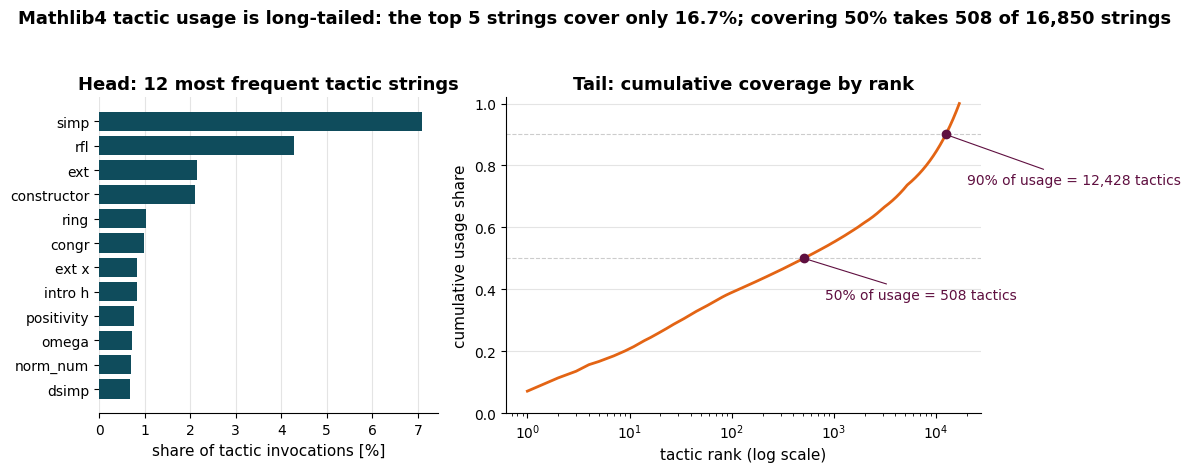

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [1, 1.4]})

head = df.head(12).iloc[::-1]
ax1.barh(head["tactic"], 100 * head["prob"], color=PALETTE[0])
ax1.set_xlabel("share of tactic invocations [%]")
ax1.set_title("Head: 12 most frequent tactic strings")
ax1.grid(axis="x", color="0.85", linewidth=0.8, alpha=0.7)
ax1.set_axisbelow(True)
ax1.spines["left"].set_visible(False)

ranks = np.arange(1, n_tactics + 1)
ax2.plot(ranks, cum, color=PALETTE[1], linewidth=2)
ax2.set_xscale("log")
ax2.set_xlabel("tactic rank (log scale)")
ax2.set_ylabel("cumulative usage share")
ax2.set_ylim(0, 1.02)
for n_cov, q, dy in ((n50, 0.5, -0.13), (n90, 0.9, -0.16)):
    ax2.axhline(q, color="0.8", linewidth=0.8, linestyle="--")
    ax2.plot([n_cov], [q], "o", color=PALETTE[2], zorder=5)
    ax2.annotate(f"{q:.0%} of usage = {n_cov:,} tactics",
                 xy=(n_cov, q), xytext=(n_cov * 1.6, q + dy),
                 fontsize=10, color=PALETTE[2],
                 arrowprops=dict(arrowstyle="-", color=PALETTE[2], linewidth=0.8))
ax2.set_title("Tail: cumulative coverage by rank")
style_ax(ax2)

fig.suptitle(
    f"Mathlib4 tactic usage is long-tailed: the top 5 strings cover only {top5_share:.1%}; "
    f"covering 50% takes {n50:,} of {n_tactics:,} strings",
    y=1.04, fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "fig1_tactic_concentration")
plt.show()


## 2. Headline: how much of miniF2F falls to goal-blind sampling?

Neither n-gram model ever sees the goal: the unigram samples tactics by corpus frequency, the
trigram conditions only on the two preceding tactics. Yet the unigram proves 26.2% of miniF2F
Test -- about a quarter of the benchmark. All numbers below are from the same W=3, K=10, N=10 best-first evaluation on the 244 traced
theorems of miniF2F Test (see `docs/methodology.md`). The BFS-Prover paper number is an
**external reference at a vastly larger budget** (2048 x 2 x 600, arXiv:2502.03438) and is shown
for context only.

saved figures/fig2_headline_comparison.png (+ .svg)


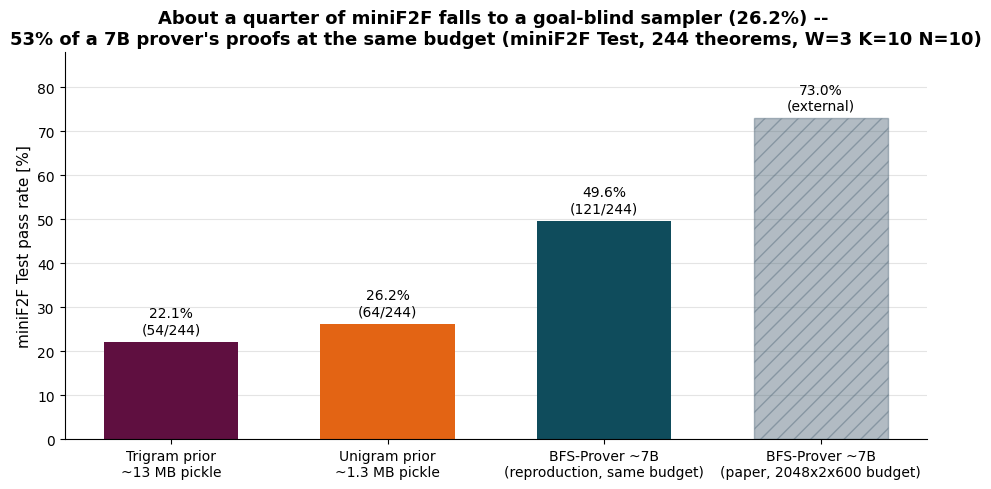

unigram/prover solved ratio at equal budget: 64/121 = 52.9%
pass-rate ratio: 26.2 / 49.6 = 52.8%


In [4]:
# (label, solved, total_or_None, color, external)
rows = [
    ("Trigram prior\n~13 MB pickle", 54, 244, PALETTE[2], False),
    ("Unigram prior\n~1.3 MB pickle", 64, 244, PALETTE[1], False),
    ("BFS-Prover ~7B\n(reproduction, same budget)", 121, 244, PALETTE[0], False),
    ("BFS-Prover ~7B\n(paper, 2048x2x600 budget)", None, None, PALETTE[4], True),
]
PAPER_RATE = 72.95  # arXiv:2502.03438, miniF2F Test

labels = [r[0] for r in rows]
rates = [100 * r[1] / r[2] if not r[4] else PAPER_RATE for r in rows]
colors = [r[3] for r in rows]

ratio = 64 / 121  # unigram solved / prover solved, same budget

fig, ax = plt.subplots(figsize=(9.5, 5))
bars = ax.bar(labels, rates, color=colors, width=0.62)
bars[-1].set_alpha(0.45)
bars[-1].set_hatch("//")
bars[-1].set_edgecolor(PALETTE[4])

for bar, row, rate in zip(bars, rows, rates):
    note = f"{rate:.1f}%" + (f"\n({row[1]}/{row[2]})" if not row[4] else "\n(external)")
    ax.annotate(note, xy=(bar.get_x() + bar.get_width() / 2, rate),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=10)

ax.set_ylabel("miniF2F Test pass rate [%]")
ax.set_ylim(0, 88)
style_ax(ax)
ax.set_title(
    f"About a quarter of miniF2F falls to a goal-blind sampler ({100 * 64 / 244:.1f}%) -- \n"
    f"{ratio:.0%} of a 7B prover's proofs at the same budget (miniF2F Test, 244 theorems, W=3 K=10 N=10)",
    fontsize=13)
fig.tight_layout()
save_fig(fig, "fig2_headline_comparison")
plt.show()

print(f"unigram/prover solved ratio at equal budget: 64/121 = {ratio:.1%}")
print(f"pass-rate ratio: 26.2 / 49.6 = {26.2 / 49.6:.1%}")


## 3. Solved-set overlap: are the priors a strict subset of the prover?

`artifacts/solved_indexes.json` holds per-model indexes of solved miniF2F Test theorems,
exported from the cluster comparison script. **Caveat:** this is an intermediate snapshot --
its set sizes (98/44/50) are smaller than the final aggregated counts (121/64/54) because it
predates the last passes of each run. Overlap statements below are therefore about the
snapshot sets and are labelled as such (see `docs/methodology.md`, Limitations). The final
per-pass evaluation logs live on the university cluster and are not distributed with this
repository.

In [5]:
solved = json.load(open(ART / "solved_indexes.json", encoding="utf-8"))
B = set(solved["bfs_prover"])
U = set(solved["unigram"])
T = set(solved["trigram"])
print(f"snapshot sizes: BFS-Prover {len(B)}, unigram {len(U)}, trigram {len(T)}")

only_U = U - B - T
only_T = T - B - U
only_B = B - U - T
UT_not_B = (U & T) - B
UB_not_T = (U & B) - T
TB_not_U = (T & B) - U
UTB = U & T & B

combos = [
    ("BFS only", only_B, (1, 0, 0)),
    ("all three", UTB, (1, 1, 1)),
    ("BFS & unigram", UB_not_T, (1, 1, 0)),
    ("BFS & trigram", TB_not_U, (1, 0, 1)),
    ("unigram & trigram\n(not BFS)", UT_not_B, (0, 1, 1)),
    ("unigram only", only_U, (0, 1, 0)),
    ("trigram only", only_T, (0, 0, 1)),
]
combos.sort(key=lambda c: -len(c[1]))

baseline_union_minus_B = (U | T) - B
print(f"solved by unigram but missed by BFS-Prover:  {len(U - B)}  -> {sorted(U - B)}")
print(f"solved by trigram but missed by BFS-Prover:  {len(T - B)}  -> {sorted(T - B)}")
print(f"solved by either baseline, missed by prover: {len(baseline_union_minus_B)}")
print(f"strict subset? {'yes' if len(baseline_union_minus_B) == 0 else 'NO'}")


snapshot sizes: BFS-Prover 98, unigram 44, trigram 50
solved by unigram but missed by BFS-Prover:  2  -> [3, 51]
solved by trigram but missed by BFS-Prover:  5  -> [3, 10, 51, 95, 126]
solved by either baseline, missed by prover: 5
strict subset? NO


saved figures/fig3_solved_overlap.png (+ .svg)


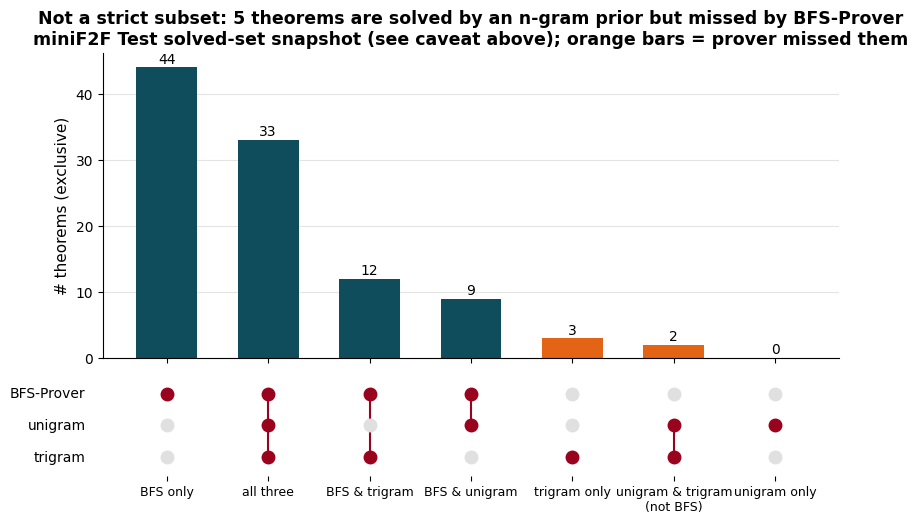

In [6]:
set_names = ["BFS-Prover", "unigram", "trigram"]
sizes = [len(c[1]) for c in combos]

fig, (ax_bar, ax_dot) = plt.subplots(
    2, 1, figsize=(9.5, 5.5), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})

x = np.arange(len(combos))
bar_colors = [PALETTE[0] if c[2][0] else PALETTE[1] for c in combos]
ax_bar.bar(x, sizes, color=bar_colors, width=0.6)
for xi, s in zip(x, sizes):
    ax_bar.annotate(str(s), xy=(xi, s), xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=10)
ax_bar.set_ylabel("# theorems (exclusive)")
style_ax(ax_bar)
n_extra = len(baseline_union_minus_B)
ax_bar.set_title(
    f"Not a strict subset: {n_extra} theorems are solved by an n-gram prior but missed by "
    "BFS-Prover\nminiF2F Test solved-set snapshot (see caveat above); orange bars = prover missed them",
    fontsize=12.5)

for row, name in enumerate(set_names):
    for xi, combo in enumerate(combos):
        member = combo[2][row]
        ax_dot.plot([xi], [row], "o", markersize=9,
                    color=PALETTE[3] if member else "0.88", zorder=3)
    ax_dot.text(-0.8, row, name, ha="right", va="center", fontsize=10)
for xi, combo in enumerate(combos):
    rows_in = [r for r in range(3) if combo[2][r]]
    if len(rows_in) > 1:
        ax_dot.plot([xi, xi], [min(rows_in), max(rows_in)], color=PALETTE[3], linewidth=1.5)
ax_dot.set_ylim(-0.6, 2.6)
ax_dot.set_yticks([])
ax_dot.set_xticks(x)
ax_dot.set_xticklabels([c[0] for c in combos], fontsize=9)
ax_dot.invert_yaxis()
for spine in ax_dot.spines.values():
    spine.set_visible(False)

save_fig(fig, "fig3_solved_overlap")
plt.show()


## 4. Held-out next-tactic prediction, and why trigram < unigram in *search*

The proof-search result is counter-intuitive: adding context (trigram) *lowered* the miniF2F
pass rate vs. the context-free unigram (22.1% vs 26.2%). Two candidate explanations:

- **(a) worse model**: the trigram is simply a worse predictor of the next tactic; or
- **(b) worse proposal behaviour**: the trigram predicts well but *proposes* poorly during
  search -- e.g. its conditional supports are tiny, so the W=3 sampler is forced into its
  with-replacement branch, wasting candidates on duplicates and on `@PSEUDO_TACTIC@`
  placeholders that get materialised as uniformly random rare tactics.

We measure both on the held-out `random/val.json` split: top-k next-tactic accuracy for each
model, plus the search-relevant pathologies (support size, placeholder mass, unseen contexts).

In [7]:
bench_dir = os.environ.get("LEANDOJO_BENCHMARK_4_DIR")
val_path = Path(bench_dir) / "random" / "val.json" if bench_dir else None
HAS_VAL = val_path is not None and val_path.exists()
if not HAS_VAL:
    print("LEANDOJO_BENCHMARK_4_DIR not set (or val.json missing) -- skipping section 4.")
else:
    trigram = load_legacy_pickle(ART / "trigram_mathlib4.pkl")
    unigram = UnigramTacticsModel(ART / "empirical_tactics_probability_mathlib4.csv")
    proofs_val = json.load(val_path.open(encoding="utf-8"))
    print(f"trigram: {len(trigram.model):,} contexts, "
          f"{len(trigram.trigram_tactics):,} frequent tactics, "
          f"{len(trigram.pseudo_tactics):,} pseudo-pool (rare) tactics")
    print(f"val split: {len(proofs_val):,} traced theorems")


trigram: 20,120 contexts, 5,219 frequent tactics, 174,134 pseudo-pool (rare) tactics
val split: 2,000 traced theorems


In [8]:
if HAS_VAL:
    SOS = TrigramTacticsModel.SOS
    PLACEHOLDERS = set(TrigramTacticsModel.PLACE_HOLDERS)
    PSEUDO = TrigramTacticsModel.PSEUDO_TACTIC
    frequent_set = set(trigram.trigram_tactics) - PLACEHOLDERS

    events = []
    for proof in proofs_val:
        seq = [t["tactic"] for t in proof["traced_tactics"]]
        if not seq:
            continue
        ctx = [SOS, SOS] + [t if t in frequent_set else PSEUDO for t in seq]
        events.extend((ctx[i], ctx[i + 1], target) for i, target in enumerate(seq))

    K_LIST = (1, 5, 10)
    uni_topk = {k: set(unigram.df_tactics_data["tactic"].head(k)) for k in K_LIST}

    def trigram_topk(w1, w2, kmax=10):
        """Top-k real tactics with the same backoff chain the search sampler uses."""
        for c in ((w1, w2), (SOS, w1), (SOS, SOS)):
            dist = trigram.model.get(c)
            if dist:
                pairs = sorted(dist.items(), key=lambda kv: -kv[1])
                return [t for t, _ in pairs if t not in PLACEHOLDERS][:kmax], c == (w1, w2)
        return [], False

    W_SEARCH = 3  # search used W=3; sampler needs support >= W + 3 placeholders
    uni_hits = dict.fromkeys(K_LIST, 0)
    tri_hits = dict.fromkeys(K_LIST, 0)
    n_seen = 0
    pseudo_mass = 0.0
    eos_mass = 0.0
    cond_entropy = 0.0
    n_small_support = 0
    n_rare_target = 0

    for w1, w2, target in events:
        if target not in frequent_set:
            n_rare_target += 1
        for k in K_LIST:
            uni_hits[k] += target in uni_topk[k]
        preds, direct = trigram_topk(w1, w2)
        for k in K_LIST:
            tri_hits[k] += target in preds[:k]
        if direct:
            n_seen += 1
            dist = trigram.model[(w1, w2)]
            pseudo_mass += dist.get(PSEUDO, 0.0)
            eos_mass += dist.get(TrigramTacticsModel.EOS, 0.0)
            n_small_support += len(dist) < W_SEARCH + len(PLACEHOLDERS)
            arr = np.array([p for p in dist.values() if p > 0])
            cond_entropy += float(-(arr * np.log2(arr)).sum())

    n_events = len(events)
    uni_acc = {k: uni_hits[k] / n_events for k in K_LIST}
    tri_acc = {k: tri_hits[k] / n_events for k in K_LIST}
    seen_rate = n_seen / n_events
    ph_pseudo = pseudo_mass / n_seen
    ph_eos = eos_mass / n_seen
    ph_mass = ph_pseudo + ph_eos
    small_rate = n_small_support / n_seen
    tri_entropy = cond_entropy / n_seen

    p_uni = unigram.probabilities.to_numpy()
    uni_entropy = float(-(p_uni * np.log2(p_uni)).sum())

    print(f"held-out next-tactic events: {n_events:,}")
    print(f"targets outside the trigram's frequent vocabulary: {n_rare_target / n_events:.1%}")
    for k in K_LIST:
        print(f"top-{k:>2} accuracy:  unigram {uni_acc[k]:6.1%}   trigram {tri_acc[k]:6.1%}")
    print()
    print("search-relevant trigram pathologies (over held-out contexts):")
    print(f"  context seen in training:              {seen_rate:.1%} "
          f"(else back off to (SOS, w1))")
    print(f"  mean mass on @PSEUDO_TACTIC@:          {ph_pseudo:.1%} "
          f"(sampled pseudo -> uniformly random tactic from a "
          f"{len(trigram.pseudo_tactics):,}-tactic rare pool)")
    print(f"  mean mass on @PROOF_END@:              {ph_eos:.1%} "
          f"(also materialised as a random rare tactic by the sampler)")
    print(f"  contexts with support < {W_SEARCH + 3} (forces sampling"
          f" with replacement at W={W_SEARCH}): {small_rate:.1%}")
    print(f"  proposal diversity: unigram entropy {uni_entropy:.1f} bits vs "
          f"trigram conditional entropy {tri_entropy:.1f} bits (event-weighted)")


held-out next-tactic events: 4,413
targets outside the trigram's frequent vocabulary: 77.0%
top- 1 accuracy:  unigram   2.4%   trigram   3.9%
top- 5 accuracy:  unigram   5.9%   trigram   7.7%
top-10 accuracy:  unigram   7.3%   trigram   8.8%

search-relevant trigram pathologies (over held-out contexts):
  context seen in training:              98.3% (else back off to (SOS, w1))
  mean mass on @PSEUDO_TACTIC@:          63.3% (sampled pseudo -> uniformly random tactic from a 174,134-tactic rare pool)
  mean mass on @PROOF_END@:              15.1% (also materialised as a random rare tactic by the sampler)
  contexts with support < 6 (forces sampling with replacement at W=3): 11.8%
  proposal diversity: unigram entropy 11.3 bits vs trigram conditional entropy 2.6 bits (event-weighted)


saved figures/fig4_heldout_prediction.png (+ .svg)


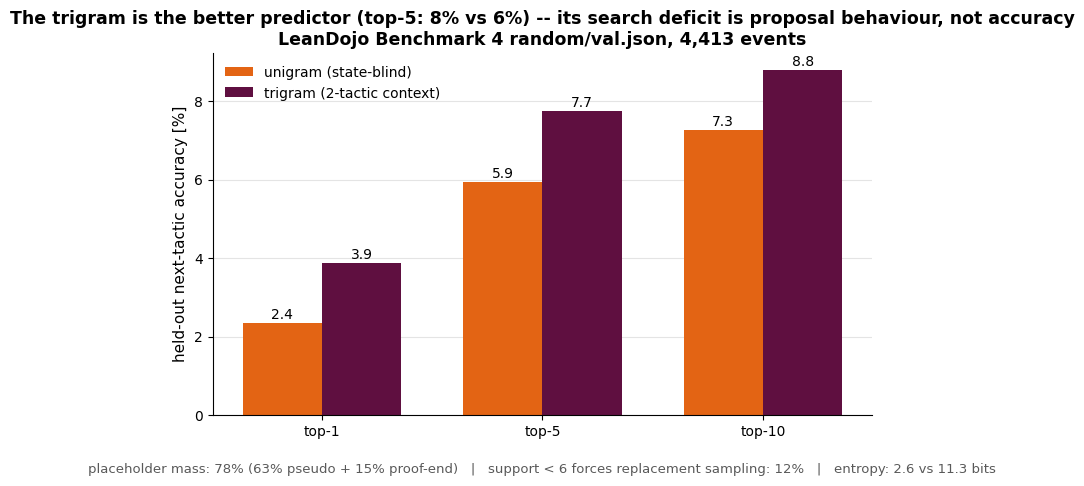

In [9]:
if HAS_VAL:
    fig, ax = plt.subplots(figsize=(9, 5))
    xs = np.arange(len(K_LIST))
    width = 0.36
    ax.bar(xs - width / 2, [100 * uni_acc[k] for k in K_LIST], width,
           label="unigram (state-blind)", color=PALETTE[1])
    ax.bar(xs + width / 2, [100 * tri_acc[k] for k in K_LIST], width,
           label="trigram (2-tactic context)", color=PALETTE[2])
    for dx, accs in ((-width / 2, uni_acc), (width / 2, tri_acc)):
        for xi, k in zip(xs, K_LIST):
            ax.annotate(f"{100 * accs[k]:.1f}", xy=(xi + dx, 100 * accs[k]),
                        xytext=(0, 3), textcoords="offset points", ha="center", fontsize=10)
    ax.set_xticks(xs)
    ax.set_xticklabels([f"top-{k}" for k in K_LIST])
    ax.set_ylabel("held-out next-tactic accuracy [%]")
    ax.legend(frameon=False, loc="upper left")
    style_ax(ax)

    if tri_acc[5] > uni_acc[5]:
        headline = (f"The trigram is the better predictor (top-5: {tri_acc[5]:.0%} vs "
                    f"{uni_acc[5]:.0%}) -- its search deficit is proposal behaviour, not accuracy")
    else:
        headline = (f"The trigram does not out-predict the unigram on held-out proofs "
                    f"(top-5: {tri_acc[5]:.0%} vs {uni_acc[5]:.0%})")
    ax.set_title(headline + f"\nLeanDojo Benchmark 4 random/val.json, {n_events:,} events",
                 fontsize=12.5)

    note = (f"placeholder mass: {ph_mass:.0%} ({ph_pseudo:.0%} pseudo + {ph_eos:.0%} proof-end)"
            f"   |   support < 6 forces replacement sampling: {small_rate:.0%}"
            f"   |   entropy: {tri_entropy:.1f} vs {uni_entropy:.1f} bits")
    ax.annotate(note, xy=(0.5, -0.16), xycoords="axes fraction", ha="center", fontsize=9.5,
                color="0.35")
    fig.tight_layout()
    save_fig(fig, "fig4_heldout_prediction")
    plt.show()


### Reading of section 4 (honest)

The cell above prints the measured quantities; the printed numbers, not this text, are the
result. Whichever way the top-k comparison lands, the trigram's *search-time* proposal
distribution differs from its *prediction* quality through measured channels: probability
mass reserved for placeholders (a sampled `@PSEUDO_TACTIC@` or `@PROOF_END@` is materialised
as a uniformly random tactic from the rare pool, which almost never type-checks on the goal
at hand), small conditional supports that force the W=3 sampler into its with-replacement
branch (duplicate candidates burn budget), and much lower proposal entropy, which shrinks
the diversity gained from K=10 independent passes. The unigram pays none of these costs:
its support is the entire frequency table and its samples are distinct by construction.
This is a candidate explanation, not a causal proof; a proper ablation (e.g. trigram without
the pseudo-tactic mechanism, or with placeholder renormalisation instead of materialisation)
requires the cluster evaluation.